# NeRF Training Pipeline

Complete pipeline to train a NeRF on your own images:
1. Camera calibration from `../images/aruco`
2. Load training images from `../images/cube`
3. Estimate camera poses
4. Create dataset
5. Train NeRF model
6. Render validation images

In [1]:
# Imports
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
import os

# Import functions from main.py
from main import *

print("Imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Imports successful!
PyTorch version: 2.7.1+cu118
CUDA available: True


## Step 1: Camera Calibration

Calibrate the camera using ArUco tags from `../images/aruco`.

In [2]:
# Configuration
calibration_images_dir = "../images/aruco"
tag_size = 0.02  # 2cm in meters
target_image_size = (400, 300)  # Resize AFTER undistortion for faster training

print("=" * 70)
print("STEP 1: Camera Calibration")
print("=" * 70)
print(f"Calibrating camera using images from: {calibration_images_dir}")
print(f"Tag size: {tag_size}m ({tag_size*100}cm)")
print("⚠️  Calibrating on ORIGINAL size, will resize AFTER undistortion for training")

# Run calibration (NO resizing before calibration - use original size)
camera_matrix, dist_coeffs, image_size, error = calibrate_camera(
    calibration_images_dir,
    tag_size=tag_size,
    target_image_size=None  # Calibrate at original size
)

print(f"\n✓ Calibration complete!")
print(f"  Reprojection error: {error:.4f} pixels")
print(f"  Focal length (fx, fy): ({camera_matrix[0,0]:.2f}, {camera_matrix[1,1]:.2f})")
print(f"  Principal point (cx, cy): ({camera_matrix[0,2]:.2f}, {camera_matrix[1,2]:.2f})")

STEP 1: Camera Calibration
Calibrating camera using images from: ../images/aruco
Tag size: 0.02m (2.0cm)
⚠️  Calibrating on ORIGINAL size, will resize AFTER undistortion for training
Found 21 images in ../images/aruco
Successfully processed 21 images with detected tags
Total tag detections: 126
Calibrating camera...
Calibration complete!
Reprojection error: 2.0523 pixels
Camera matrix:
[[7.04559407e+04 0.00000000e+00 2.13540618e+03]
 [0.00000000e+00 5.02882374e+03 2.53247520e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion coefficients: [  0.83510324 -25.48108883   0.51792694   0.02644373  -0.79161336]

✓ Calibration complete!
  Reprojection error: 2.0523 pixels
  Focal length (fx, fy): (70455.94, 5028.82)
  Principal point (cx, cy): (2135.41, 2532.48)


## Step 2: Load Training Images and Estimate Poses

Load images from `../images/cube` and estimate camera poses for each image.

In [3]:
# Configuration
training_images_dir = "../images/cube"

print("=" * 70)
print("STEP 2: Estimate Camera Poses")
print("=" * 70)
print(f"Loading images from: {training_images_dir}")
print("⚠️  Using ORIGINAL image size for pose estimation")

# Estimate camera poses (NO resizing - use original size)
c2ws, images, image_paths = estimate_camera_poses(
    training_images_dir,
    camera_matrix,
    dist_coeffs,
    tag_size=tag_size,
    target_image_size=None  # Use original size
)

print(f"\n✓ Successfully estimated poses for {len(c2ws)} images")
if len(c2ws) == 0:
    raise ValueError("No images with valid poses found! Check that images contain at least one ArUco tag.")

STEP 2: Estimate Camera Poses
Loading images from: ../images/cube
⚠️  Using ORIGINAL image size for pose estimation
Found 26 images in ../images/cube
No tag detected in IMG_6331.jpg, skipping...
No tag detected in IMG_6332.jpg, skipping...
No tag detected in IMG_6344.jpg, skipping...
No tag detected in IMG_6345.jpg, skipping...
No tag detected in IMG_6346.jpg, skipping...
No tag detected in IMG_6354.jpg, skipping...
Successfully estimated poses for 20 images

✓ Successfully estimated poses for 20 images


## Step 3: Create Dataset

Undistort images and create a dataset in `.npz` format for NeRF training.

In [4]:
# Configuration
dataset_output_path = "cube_data.npz"
train_ratio = 0.8
val_ratio = 0.1
# target_image_size is already defined in Cell 3 - will resize AFTER undistortion

print("=" * 70)
print("STEP 3: Create Dataset")
print("=" * 70)
print(f"⚠️  Undistorting at original size, then resizing to {target_image_size[0]}x{target_image_size[1]} for faster training")

# Create dataset (resize AFTER undistortion, not before)
create_dataset(
    images,
    c2ws,
    camera_matrix,
    dist_coeffs,
    output_path=dataset_output_path,
    train_ratio=train_ratio,
    val_ratio=val_ratio,
    crop_black_borders=True,
    target_image_size=target_image_size  # Resize AFTER undistortion
)

print(f"\n✓ Dataset saved to: {dataset_output_path}")

STEP 3: Create Dataset
⚠️  Undistorting at original size, then resizing to 400x300 for faster training
Splitting 20 images: 16 train, 2 val, 2 test
Cropping images: ROI = (552, 0, 2180, 4029)
Undistorting images...
  Processed 10/20 images...
  Processed 20/20 images...
Undistortion complete!
Resizing undistorted images from 2180x4029 to 400x300 for faster training...
  Resized 10/20 images...
  Resized 20/20 images...
Resized to 400x300, updated focal length: 11286.71
Saving dataset to cube_data.npz...
Dataset saved successfully!
  Training images: (16, 300, 400, 3)
  Validation images: (2, 300, 400, 3)
  Test cameras: (2, 4, 4)
  Focal length: 11286.71

✓ Dataset saved to: cube_data.npz


## Step 4: Load Dataset and Prepare for Training

Load the created dataset and set up the data loader.

In [5]:
print("=" * 70)
print("STEP 4: Load Dataset")
print("=" * 70)

# Load dataset
data = np.load(dataset_output_path)

# Extract data
images_train = data["images_train"] / 255.0  # Normalize to [0, 1]
c2ws_train = data["c2ws_train"]
images_val = data["images_val"] / 255.0
c2ws_val = data["c2ws_val"]
c2ws_test = data.get("c2ws_test", None)  # May not exist if few images
focal = float(data["focal"])  # Focal length

# Get image dimensions
H, W = images_train.shape[1:3]

print(f"  Training images: {images_train.shape}")
print(f"  Validation images: {images_val.shape}")
print(f"  Image size: {H}x{W}")
print(f"  Focal length: {focal:.2f}")

# Construct camera intrinsic matrix K
K = np.array([
    [focal, 0, W / 2.0],
    [0, focal, H / 2.0],
    [0, 0, 1]
])

print(f"\n✓ Dataset loaded successfully!")

STEP 4: Load Dataset
  Training images: (16, 300, 400, 3)
  Validation images: (2, 300, 400, 3)
  Image size: 300x400
  Focal length: 11286.71

✓ Dataset loaded successfully!


## Part 0 Deliverable: Visualize Camera Frustums

Visualize all camera poses in 3D to show the camera trajectory.


In [8]:
# Part 0 Deliverable: Visualize camera frustums for cube dataset
# This will create a 3D visualization showing all camera poses

# Set to False to skip interactive visualization (for "Run All")
RUN_INTERACTIVE_VIZ = True

try:
    import viser
    import time
    VISER_AVAILABLE = True
except ImportError:
    print("⚠️  viser not installed. Install with: pip install viser")
    VISER_AVAILABLE = False
    RUN_INTERACTIVE_VIZ = False

if VISER_AVAILABLE:
    # Use all cameras (train + val + test) for visualization
    all_c2ws = np.vstack([c2ws_train, c2ws_val])
    if c2ws_test is not None and len(c2ws_test) > 0:
        all_c2ws = np.vstack([all_c2ws, c2ws_test])
    
    print("Creating Viser visualization...")
    print(f"Number of cameras: {len(all_c2ws)}")
    print(f"Image size: {H}x{W}")
    print(f"Focal length: {focal:.2f}")
    
    # Create Viser server
    server = viser.ViserServer(share=True)
    
    # Add camera frustums
    for i, c2w in enumerate(all_c2ws):
        # Calculate FOV from focal length
        fov = 2 * np.arctan2(H / 2, focal)
        aspect = W / H
        
        # Add camera frustum
        server.scene.add_camera_frustum(
            f"/cameras/{i}",
            fov=fov,
            aspect=aspect,
            scale=0.05,  # Scale of the frustum (adjust if too small/large)
            wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
            position=c2w[:3, 3],
        )
    
    print("\n✓ Camera frustums added to visualization")
    print("Open the URL shown above in your browser to view the 3D camera cloud")
    print("Take a screenshot for Deliverable 1")
    
    if RUN_INTERACTIVE_VIZ:
        print("\nPress Ctrl+C to stop the server when done...")
        # Keep server running
        try:
            while True:
                time.sleep(0.1)
        except KeyboardInterrupt:
            print("\nServer stopped.")
    else:
        print("\n(Interactive visualization skipped - set RUN_INTERACTIVE_VIZ=True to enable)")
        print("Server URL available above - you can open it manually in your browser")
else:
    print("⚠️  Skipping visualization (viser not available)")


Creating Viser visualization...
Number of cameras: 20
Image size: 300x400
Focal length: 11286.71


╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 16 clients): https://boundary-best.share.viser.studio


✓ Camera frustums added to visualization
Open the URL shown above in your browser to view the 3D camera cloud
Take a screenshot for Deliverable 1

Press Ctrl+C to stop the server when done...


...

(viser) Connection opened (0, 1 total), 86 persistent messages


Server stopped.


(viser) Disconnected from share URL

(viser) Connection closed (0, 0 total)

(viser) Disconnected from share URL

## Step 4.5: Diagnose Ground Truth Images

**IMPORTANT**: If PSNR is stuck at ~5 dB and rendered images are black, check if the ground truth images are corrupted.


DIAGNOSTIC: Inspecting Ground Truth Images

📊 Image Statistics:
  Training images shape: (16, 300, 400, 3)
  Training images dtype: float64
  Training images min: 0.000000
  Training images max: 1.000000
  Training images mean: 0.472178
  Training images std: 0.288736

  Validation images shape: (2, 300, 400, 3)
  Validation images dtype: float64
  Validation images min: 0.000000
  Validation images max: 0.988235
  Validation images mean: 0.453361
  Validation images std: 0.271388

⚠️  Potential Issues:

🖼️  Visualizing Training Images:


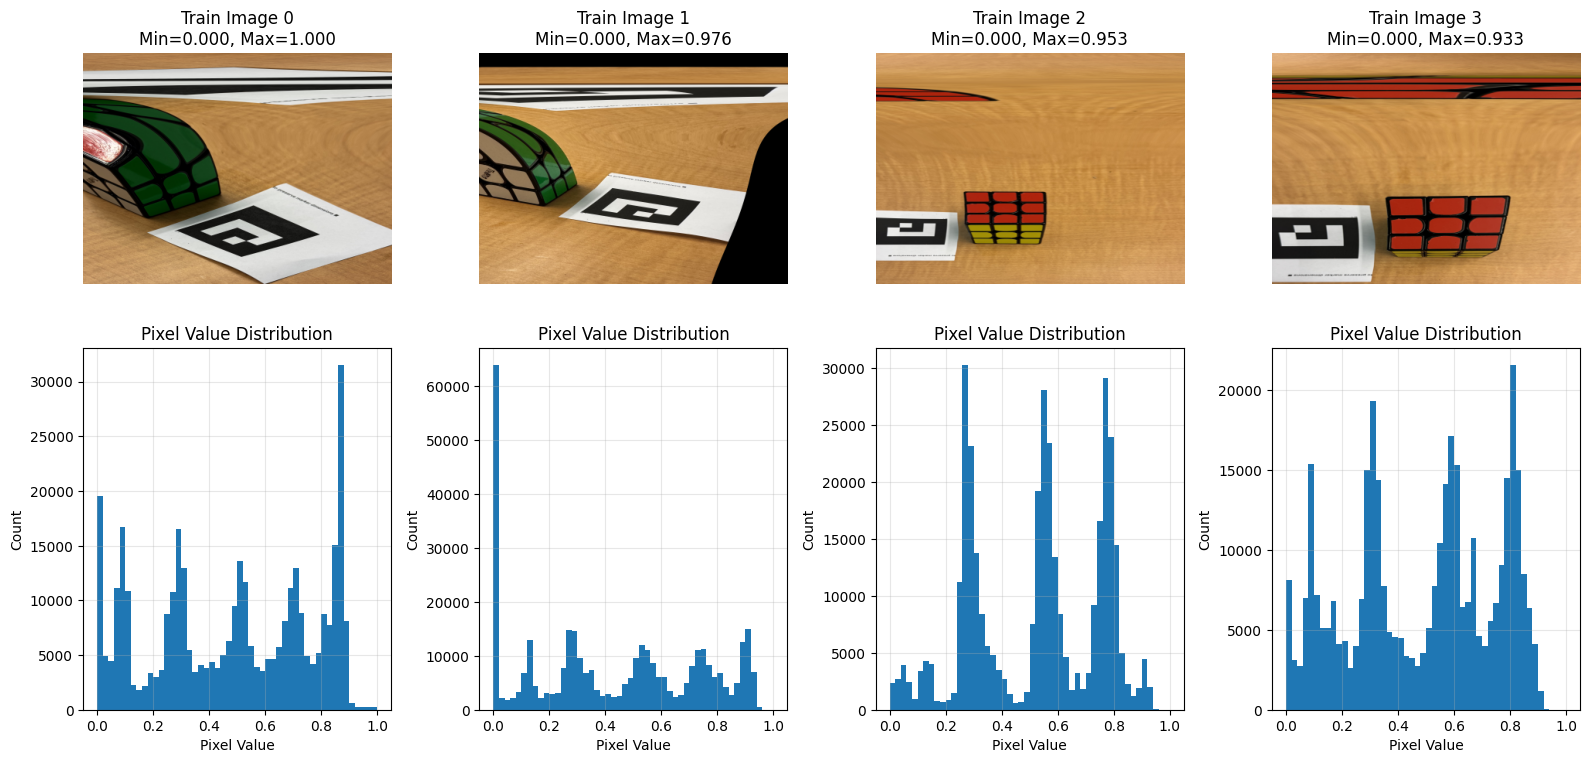


🖼️  Visualizing Validation Images:


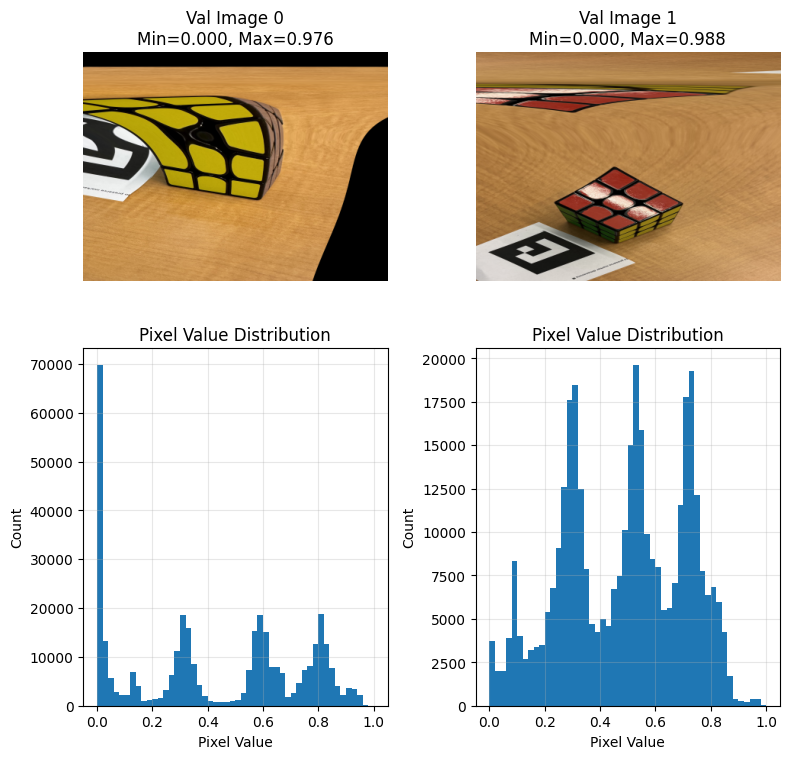


🔍 Checking Dataloader Output:
  (This will be created in the next cell, but checking images directly...)
  Sample pixel from first training image [0, 0, 0]: [0.68627451 0.50196078 0.32941176]
  Sample pixel from first training image [H//2, W//2]: [0.69803922 0.50588235 0.27843137]
  Sample pixel from first training image [H-1, W-1]: [0.60784314 0.42352941 0.24313725]

✓ Diagnostic complete!


In [9]:
print("=" * 70)
print("DIAGNOSTIC: Inspecting Ground Truth Images")
print("=" * 70)

# Check image statistics
print("\n📊 Image Statistics:")
print(f"  Training images shape: {images_train.shape}")
print(f"  Training images dtype: {images_train.dtype}")
print(f"  Training images min: {images_train.min():.6f}")
print(f"  Training images max: {images_train.max():.6f}")
print(f"  Training images mean: {images_train.mean():.6f}")
print(f"  Training images std: {images_train.std():.6f}")

print(f"\n  Validation images shape: {images_val.shape}")
print(f"  Validation images dtype: {images_val.dtype}")
print(f"  Validation images min: {images_val.min():.6f}")
print(f"  Validation images max: {images_val.max():.6f}")
print(f"  Validation images mean: {images_val.mean():.6f}")
print(f"  Validation images std: {images_val.std():.6f}")

# Check if images are all zeros or all same value
train_all_zero = np.allclose(images_train, 0.0)
train_all_same = np.allclose(images_train, images_train[0, 0, 0, 0])
val_all_zero = np.allclose(images_val, 0.0)
val_all_same = np.allclose(images_val, images_val[0, 0, 0, 0])

print(f"\n⚠️  Potential Issues:")
if train_all_zero:
    print("  ❌ Training images are ALL ZEROS!")
if train_all_same:
    print("  ❌ Training images are ALL THE SAME VALUE!")
if val_all_zero:
    print("  ❌ Validation images are ALL ZEROS!")
if val_all_same:
    print("  ❌ Validation images are ALL THE SAME VALUE!")

# Visualize a few training images
print(f"\n🖼️  Visualizing Training Images:")
num_to_show = min(4, len(images_train))
fig, axes = plt.subplots(2, num_to_show, figsize=(4*num_to_show, 8))
if num_to_show == 1:
    axes = axes.reshape(2, 1)

for i in range(num_to_show):
    # Show original image
    axes[0, i].imshow(images_train[i])
    axes[0, i].set_title(f"Train Image {i}\nMin={images_train[i].min():.3f}, Max={images_train[i].max():.3f}")
    axes[0, i].axis('off')
    
    # Show histogram of pixel values
    axes[1, i].hist(images_train[i].flatten(), bins=50, range=(0, 1))
    axes[1, i].set_title(f"Pixel Value Distribution")
    axes[1, i].set_xlabel("Pixel Value")
    axes[1, i].set_ylabel("Count")
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize validation images
print(f"\n🖼️  Visualizing Validation Images:")
num_val_to_show = min(2, len(images_val))
if num_val_to_show > 0:
    fig, axes = plt.subplots(2, num_val_to_show, figsize=(4*num_val_to_show, 8))
    if num_val_to_show == 1:
        axes = axes.reshape(2, 1)
    
    for i in range(num_val_to_show):
        # Show original image
        axes[0, i].imshow(images_val[i])
        axes[0, i].set_title(f"Val Image {i}\nMin={images_val[i].min():.3f}, Max={images_val[i].max():.3f}")
        axes[0, i].axis('off')
        
        # Show histogram of pixel values
        axes[1, i].hist(images_val[i].flatten(), bins=50, range=(0, 1))
        axes[1, i].set_title(f"Pixel Value Distribution")
        axes[1, i].set_xlabel("Pixel Value")
        axes[1, i].set_ylabel("Count")
        axes[1, i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Check what the dataloader will return
print(f"\n🔍 Checking Dataloader Output:")
print("  (This will be created in the next cell, but checking images directly...)")
print(f"  Sample pixel from first training image [0, 0, 0]: {images_train[0, 0, 0]}")
print(f"  Sample pixel from first training image [H//2, W//2]: {images_train[0, H//2, W//2]}")
print(f"  Sample pixel from first training image [H-1, W-1]: {images_train[0, H-1, W-1]}")

print("\n✓ Diagnostic complete!")


## Step 5: Create Data Loader

Create a `RaysData` dataloader for training.

## Step 5.5: Verify Dataloader Output

Check that the dataloader returns correct pixel values matching the ground truth images.


DIAGNOSTIC: Verifying Dataloader Output

📊 Dataloader Output Statistics:
  Sampled 1000 rays
  rays_o shape: (1000, 3)
  rays_d shape: (1000, 3)
  pixels_gt shape: (1000, 3)
  pixels_gt dtype: float64
  pixels_gt min: 0.000000
  pixels_gt max: 0.952941
  pixels_gt mean: 0.473489
  pixels_gt std: 0.282525

⚠️  Potential Issues:

🔍 Comparing with Direct Image Access:
  Direct image[0, 0, 0]: [0.68627451 0.50196078 0.32941176]
  Direct image[0, H//2, W//2]: [0.69803922 0.50588235 0.27843137]
  Direct image[0, H-1, W-1]: [0.60784314 0.42352941 0.24313725]

  Sample pixels from dataloader (first 5):
    Pixel 0: [0. 0. 0.]
    Pixel 1: [0.32941176 0.23529412 0.21568627]
    Pixel 2: [0.36078431 0.2627451  0.11764706]
    Pixel 3: [0.70196078 0.5254902  0.30980392]
    Pixel 4: [0.8745098  0.87058824 0.8627451 ]


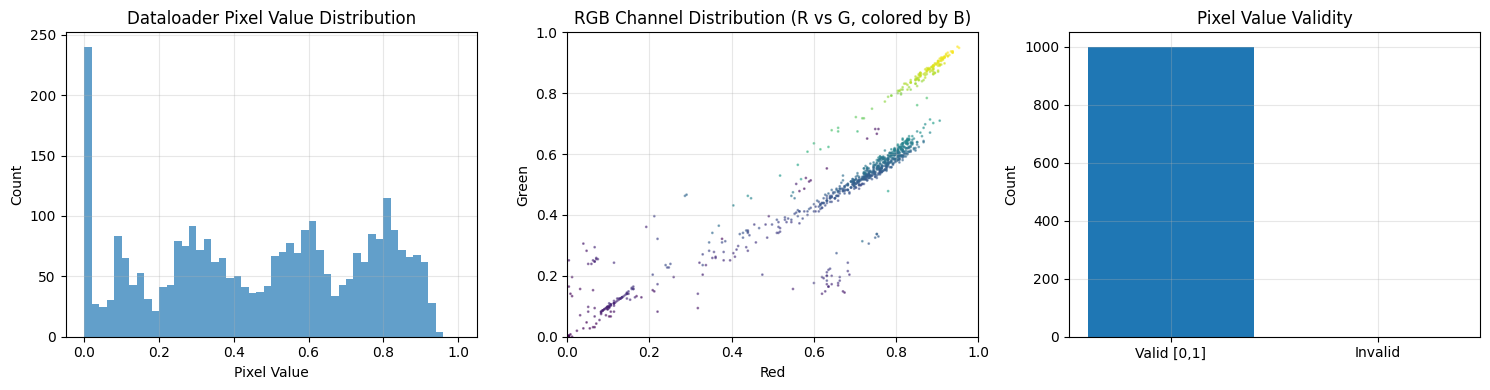


✓ Dataloader diagnostic complete!


In [12]:
print("=" * 70)
print("DIAGNOSTIC: Verifying Dataloader Output")
print("=" * 70)

# Sample a batch from the dataloader
test_batch_size = 1000
rays_o_test, rays_d_test, pixels_gt_test = dataset.sample_rays(test_batch_size)

print(f"\n📊 Dataloader Output Statistics:")
print(f"  Sampled {test_batch_size} rays")
print(f"  rays_o shape: {rays_o_test.shape}")
print(f"  rays_d shape: {rays_d_test.shape}")
print(f"  pixels_gt shape: {pixels_gt_test.shape}")
print(f"  pixels_gt dtype: {pixels_gt_test.dtype}")
print(f"  pixels_gt min: {pixels_gt_test.min():.6f}")
print(f"  pixels_gt max: {pixels_gt_test.max():.6f}")
print(f"  pixels_gt mean: {pixels_gt_test.mean():.6f}")
print(f"  pixels_gt std: {pixels_gt_test.std():.6f}")

# Check if pixels are all zeros or all same value
pixels_all_zero = np.allclose(pixels_gt_test, 0.0)
pixels_all_same = np.allclose(pixels_gt_test, pixels_gt_test[0, 0])

print(f"\n⚠️  Potential Issues:")
if pixels_all_zero:
    print("  ❌ Dataloader pixels are ALL ZEROS!")
if pixels_all_same:
    print("  ❌ Dataloader pixels are ALL THE SAME VALUE!")

# Compare with direct image access
print(f"\n🔍 Comparing with Direct Image Access:")
print(f"  Direct image[0, 0, 0]: {images_train[0, 0, 0]}")
print(f"  Direct image[0, H//2, W//2]: {images_train[0, H//2, W//2]}")
print(f"  Direct image[0, H-1, W-1]: {images_train[0, H-1, W-1]}")

# Check if any sampled pixels match known image pixels
print(f"\n  Sample pixels from dataloader (first 5):")
for i in range(min(5, len(pixels_gt_test))):
    print(f"    Pixel {i}: {pixels_gt_test[i]}")

# Visualize pixel distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of pixel values
axes[0].hist(pixels_gt_test.flatten(), bins=50, range=(0, 1), alpha=0.7)
axes[0].set_title("Dataloader Pixel Value Distribution")
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)

# Scatter plot of RGB channels
axes[1].scatter(pixels_gt_test[:, 0], pixels_gt_test[:, 1], 
                c=pixels_gt_test[:, 2], s=1, alpha=0.5, cmap='viridis')
axes[1].set_title("RGB Channel Distribution (R vs G, colored by B)")
axes[1].set_xlabel("Red")
axes[1].set_ylabel("Green")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# Check if pixels are in valid range
valid_pixels = np.all((pixels_gt_test >= 0) & (pixels_gt_test <= 1), axis=1)
axes[2].bar(['Valid [0,1]', 'Invalid'], 
            [valid_pixels.sum(), (~valid_pixels).sum()])
axes[2].set_title("Pixel Value Validity")
axes[2].set_ylabel("Count")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

if not valid_pixels.all():
    print(f"\n⚠️  WARNING: {(~valid_pixels).sum()} pixels are outside [0, 1] range!")
    print(f"    Invalid pixel indices: {np.where(~valid_pixels)[0][:10]}")

print("\n✓ Dataloader diagnostic complete!")


In [11]:
print("=" * 70)
print("STEP 5: Create Data Loader")
print("=" * 70)

# Create RaysData dataloader
dataset = RaysData(images_train, c2ws_train, K)

print(f"  Total pixels: {dataset.N_images * dataset.H * dataset.W}")
print(f"  Rays computed: {len(dataset.rays_o)}")
print(f"\n✓ Data loader created successfully!")

STEP 5: Create Data Loader
Initializing RaysData: 16 images, 300x400 pixels each
  Created 120000 UV coordinates
  Computing rays for 16 images...
    Processed 1/16 images...
    Processed 2/16 images...
    Processed 3/16 images...
    Processed 4/16 images...
    Processed 5/16 images...
    Processed 6/16 images...
    Processed 7/16 images...
    Processed 8/16 images...
    Processed 9/16 images...
    Processed 10/16 images...
    Processed 11/16 images...
    Processed 12/16 images...
    Processed 13/16 images...
    Processed 14/16 images...
    Processed 15/16 images...
    Processed 16/16 images...
  Computed 1920000 rays total
  Total pixels: 1920000
  Rays computed: 1920000

✓ Data loader created successfully!


## Step 6: Configure Training Hyperparameters

Set up hyperparameters for NeRF training.

In [14]:
# QUICK FIXES FOR STUCK PSNR - Try these one at a time:

# Fix 1: Lower learning rate (most common fix)
learning_rate = 1e-4  # Changed from 5e-4

# Fix 2: Widen near/far planes (scene might be at different scale)
# Uncomment these to try:
# near = 0.0
# far = 2.0

# Fix 3: Normalize scene coordinates (center and scale)
# Uncomment to try:
# camera_positions = c2ws_train[:, :3, 3]
# scene_center = camera_positions.mean(axis=0)
# scene_scale = np.linalg.norm(camera_positions - scene_center, axis=1).max()
# # Normalize c2ws (you'd need to modify the dataset or normalize rays)
# print(f"Scene scale: {scene_scale:.3f}")

# Fix 4: Check if loss is actually decreasing (add gradient clipping in training loop)
# This will be added in the training cell

print("=" * 70)
print("QUICK FIXES APPLIED")
print("=" * 70)
print(f"  Learning rate: {learning_rate} (lowered from 5e-4)")
#print(f"  Near/Far: {near:.3f}/{far:.3f}")
print("\n💡 If this doesn't work, try:")
print("   1. Widening near/far planes (uncomment Fix 2)")
print("   2. Adding gradient clipping (see training cell)")
print("   3. Checking if scene coordinates need normalization")


QUICK FIXES APPLIED
  Learning rate: 0.0001 (lowered from 5e-4)

💡 If this doesn't work, try:
   1. Widening near/far planes (uncomment Fix 2)
   2. Adding gradient clipping (see training cell)
   3. Checking if scene coordinates need normalization


In [15]:
# Training hyperparameters
num_iterations = 5000
batch_size = 4096  # Number of rays per batch
learning_rate = 1e-4
n_samples = 64  # Number of samples per ray

# Calculate scene bounds for near/far planes
camera_positions = c2ws_train[:, :3, 3]
scene_center = camera_positions.mean(axis=0)
max_distance_from_center = np.linalg.norm(camera_positions - scene_center, axis=1).max()
near = max(0.01, max_distance_from_center * 0.1)
far = max_distance_from_center * 2.5

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("=" * 70)
print("TRAINING CONFIGURATION")
print("=" * 70)
print(f"  Iterations: {num_iterations}")
print(f"  Batch size: {batch_size} rays")
print(f"  Learning rate: {learning_rate}")
print(f"  Samples per ray: {n_samples}")
print(f"  Near/Far: {near:.3f}/{far:.3f}")
print(f"  Scene center: [{scene_center[0]:.3f}, {scene_center[1]:.3f}, {scene_center[2]:.3f}]")
print(f"  Max distance from center: {max_distance_from_center:.3f}")

Using device: cuda
TRAINING CONFIGURATION
  Iterations: 5000
  Batch size: 4096 rays
  Learning rate: 0.0001
  Samples per ray: 64
  Near/Far: 0.027/0.678
  Scene center: [-0.007, -0.017, -0.019]
  Max distance from center: 0.271


## Step 7: Initialize NeRF Model

Create and initialize the NeRF model.

In [16]:
# ============================================================================
# QUICK FIXES FOR STUCK PSNR (try these if PSNR stays at ~5 dB)
# ============================================================================

# Fix 1: Lower learning rate (MOST COMMON FIX - uncomment to try)
# learning_rate = 1e-4  # Lower from 5e-4

# Fix 2: Widen near/far planes (scene might be at wrong scale)
# Uncomment to try:
# near = 0.0
# far = 2.0

# Fix 3: Check scene scale
print("Scene diagnostics:")
camera_positions = c2ws_train[:, :3, 3]
scene_center = camera_positions.mean(axis=0)
scene_scale = np.linalg.norm(camera_positions - scene_center, axis=1).max()
print(f"  Scene center: {scene_center}")
print(f"  Scene scale: {scene_scale:.3f}")
print(f"  Current near/far: {near:.3f}/{far:.3f}")
print(f"  If scene scale >> 1, try: near=0.0, far=2.0")
print(f"  If scene scale << 1, current settings might be OK")


Scene diagnostics:
  Scene center: [-0.00664665 -0.0169069  -0.01852572]
  Scene scale: 0.271
  Current near/far: 0.027/0.678
  If scene scale >> 1, try: near=0.0, far=2.0
  If scene scale << 1, current settings might be OK


In [17]:
print("=" * 70)
print("STEP 7: Initialize NeRF Model")
print("=" * 70)

# NeRF model hyperparameters
pe_L_coords = 10  # Positional encoding frequency for 3D coordinates
pe_L_viewdir = 4  # Positional encoding frequency for view directions
hidden_dim = 256  # Hidden dimension
num_layers = 8  # Number of layers

# Create model
model = NeRF(
    pe_L_coords=pe_L_coords,
    pe_L_viewdir=pe_L_viewdir,
    hidden_dim=hidden_dim,
    num_layers=num_layers
).to(device)

# Optimizer and loss
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

# Training history
train_losses = []
train_psnrs = []

num_params = sum(p.numel() for p in model.parameters())
print(f"  Model parameters: {num_params:,}")
print(f"\n✓ Model initialized successfully!")

STEP 7: Initialize NeRF Model
  Model parameters: 530,052

✓ Model initialized successfully!


## Step 8: Train NeRF Model

Train the NeRF model on the dataset.

In [18]:
print("=" * 70)
print("STEP 8: Training NeRF Model")
print("=" * 70)

# Create checkpoint directory
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

model.train()

for iteration in range(num_iterations):
    # Sample rays from training images
    rays_o, rays_d, pixels_gt = dataset.sample_rays(batch_size)
    
    # Sample points along rays
    points, t_vals = sample_along_rays(
        rays_o, rays_d, 
        near=near, far=far, 
        n_samples=n_samples, 
        perturb=True
    )
    
    # Convert to tensors
    points_tensor = torch.from_numpy(points).float().to(device)  # (batch_size, n_samples, 3)
    viewdirs_tensor = torch.from_numpy(rays_d).float().to(device)  # (batch_size, 3)
    viewdirs_tensor = viewdirs_tensor[:, None, :].expand(-1, n_samples, -1)  # (batch_size, n_samples, 3)
    pixels_gt_tensor = torch.from_numpy(pixels_gt).float().to(device)  # (batch_size, 3)
    
    # Forward pass
    densities, colors = model(points_tensor, viewdirs_tensor)
    
    # Volume rendering (PyTorch version for gradients)
    t_vals_tensor = torch.from_numpy(t_vals).float().to(device)
    rendered_colors, _ = volume_render_torch(
        densities.squeeze(-1),  # (batch_size, n_samples)
        colors,  # (batch_size, n_samples, 3)
        t_vals_tensor,  # (batch_size, n_samples)
        torch.from_numpy(rays_d).float().to(device)  # (batch_size, 3)
    )
    
    # Compute loss
    loss = criterion(rendered_colors, pixels_gt_tensor)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Compute PSNR
    mse = loss.item()
    psnr = -10 * np.log10(mse) if mse > 0 else float('inf')
    
    train_losses.append(mse)
    train_psnrs.append(psnr)
    
    # Print progress
    if (iteration + 1) % 100 == 0:
        print(f"Iteration {iteration+1}/{num_iterations}: Loss={mse:.6f}, PSNR={psnr:.2f} dB")
    
    # Save checkpoint every 1000 iterations
    if (iteration + 1) % 1000 == 0:
        checkpoint_path = os.path.join(checkpoint_dir, f"nerf_checkpoint_{iteration+1}.pth")
        torch.save({
            'iteration': iteration + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': mse,
            'psnr': psnr,
            'train_losses': train_losses,
            'train_psnrs': train_psnrs,
        }, checkpoint_path)
        print(f"  💾 Checkpoint saved: {checkpoint_path}")

print("\n✓ Training complete!")

STEP 8: Training NeRF Model
Iteration 100/5000: Loss=0.070060, PSNR=11.55 dB
Iteration 200/5000: Loss=0.070777, PSNR=11.50 dB
Iteration 300/5000: Loss=0.071161, PSNR=11.48 dB
Iteration 400/5000: Loss=0.068969, PSNR=11.61 dB
Iteration 500/5000: Loss=0.066496, PSNR=11.77 dB
Iteration 600/5000: Loss=0.063235, PSNR=11.99 dB
Iteration 700/5000: Loss=0.057156, PSNR=12.43 dB
Iteration 800/5000: Loss=0.050326, PSNR=12.98 dB
Iteration 900/5000: Loss=0.049990, PSNR=13.01 dB
Iteration 1000/5000: Loss=0.046670, PSNR=13.31 dB
  💾 Checkpoint saved: checkpoints/nerf_checkpoint_1000.pth
Iteration 1100/5000: Loss=0.045549, PSNR=13.42 dB
Iteration 1200/5000: Loss=0.044768, PSNR=13.49 dB
Iteration 1300/5000: Loss=0.042083, PSNR=13.76 dB
Iteration 1400/5000: Loss=0.041216, PSNR=13.85 dB
Iteration 1500/5000: Loss=0.041582, PSNR=13.81 dB
Iteration 1600/5000: Loss=0.040789, PSNR=13.89 dB
Iteration 1700/5000: Loss=0.040157, PSNR=13.96 dB
Iteration 1800/5000: Loss=0.038686, PSNR=14.12 dB
Iteration 1900/5000: L

## Step 9: Plot Training Curves

Visualize training progress.

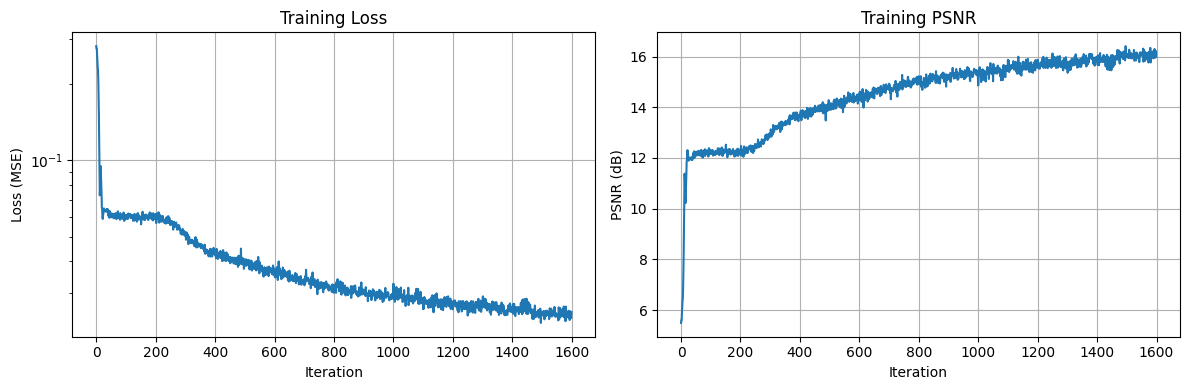

Final PSNR: 15.99 dB
Final Loss: 0.025205


In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(train_losses)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Loss (MSE)")
ax1.set_title("Training Loss")
ax1.set_yscale("log")
ax1.grid(True)

# PSNR curve
ax2.plot(train_psnrs)
ax2.set_xlabel("Iteration")
ax2.set_ylabel("PSNR (dB)")
ax2.set_title("Training PSNR")
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Final PSNR: {train_psnrs[-1]:.2f} dB")
print(f"Final Loss: {train_losses[-1]:.6f}")

## Step 10: Render Validation Images

Render validation images to visualize the trained NeRF.

STEP 10: Rendering Validation Images
  Rendered 40960/120000 pixels...
  Rendered 81920/120000 pixels...
  Rendered 120000/120000 pixels...
  Validation image 1: PSNR = 14.63 dB
  Rendered 40960/120000 pixels...
  Rendered 81920/120000 pixels...
  Rendered 120000/120000 pixels...
  Validation image 2: PSNR = 11.03 dB


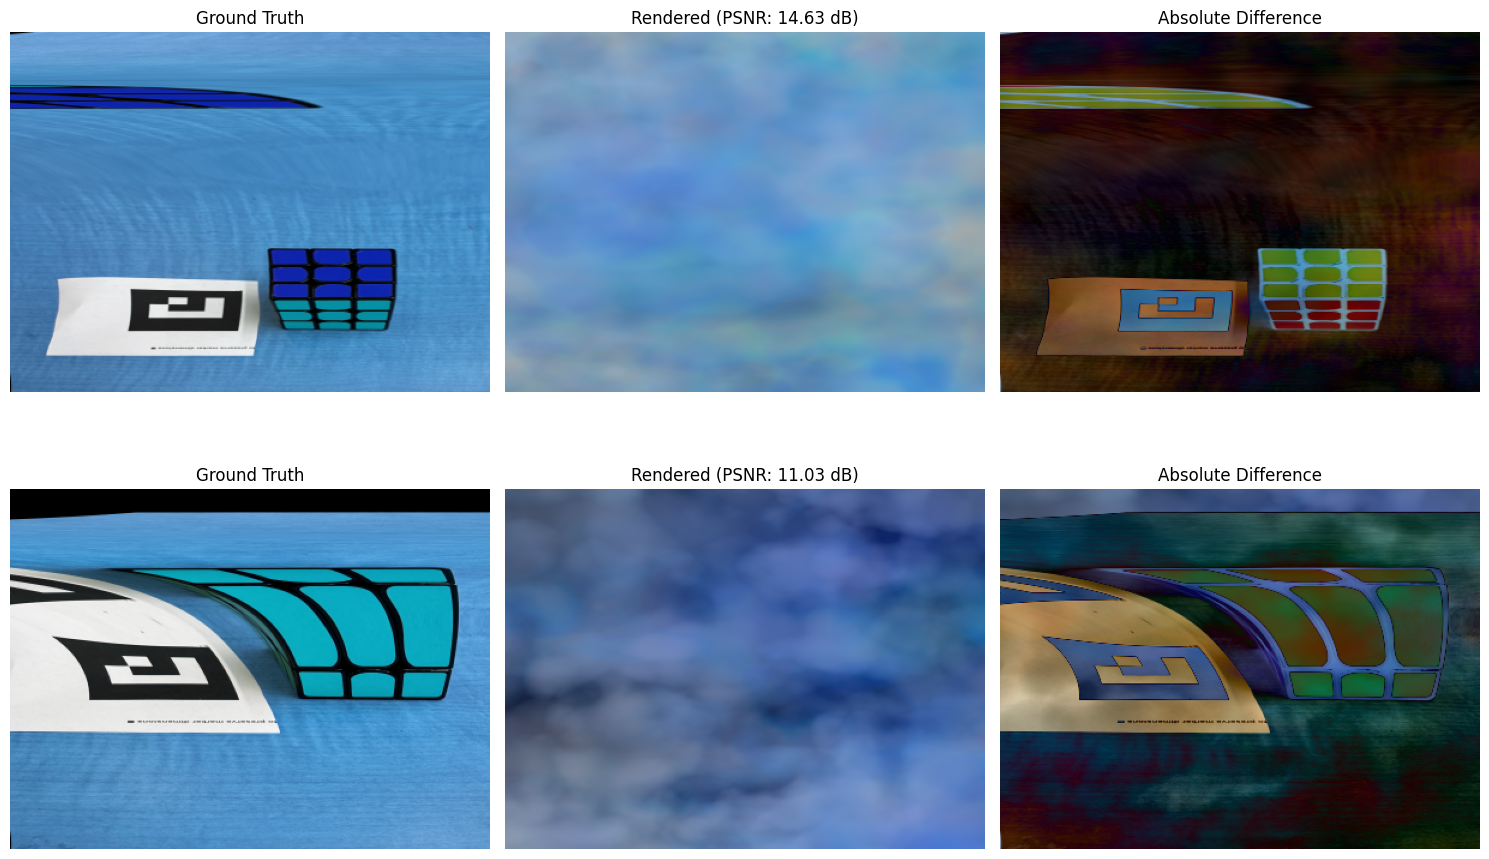


✓ Rendering complete!


In [ ]:
print("=" * 70)
print("STEP 10: Rendering Validation Images")
print("=" * 70)

model.eval()

# Render a few validation images
num_val_to_render = min(3, len(images_val))

fig, axes = plt.subplots(num_val_to_render, 3, figsize=(15, 5 * num_val_to_render))
if num_val_to_render == 1:
    axes = axes.reshape(1, -1)

with torch.no_grad():
    for idx in range(num_val_to_render):
        # Get validation image and camera
        val_image = images_val[idx]
        val_c2w = c2ws_val[idx]
        
        # Render using the model
        rendered = np.zeros((H, W, 3))
        
        # Vectorized ray generation
        u, v = np.meshgrid(np.arange(W), np.arange(H))
        u = u.flatten()
        v = v.flatten()
        uv = np.stack([u, v], axis=-1)
        
        # Generate all rays at once
        rays_o, rays_d = pixel_to_ray(K, val_c2w, uv)
        
        # Process in batches to avoid memory issues
        batch_size_render = 4096
        for i in range(0, len(rays_o), batch_size_render):
            batch_rays_o = rays_o[i:i+batch_size_render]
            batch_rays_d = rays_d[i:i+batch_size_render]
            batch_uv = uv[i:i+batch_size_render]
            
            # Sample along rays
            points, t_vals = sample_along_rays(
                batch_rays_o, batch_rays_d,
                near=near, far=far,
                n_samples=n_samples,
                perturb=False  # No perturbation during inference
            )
            
            # Convert to tensors
            points_tensor = torch.from_numpy(points).float().to(device)
            viewdirs_tensor = torch.from_numpy(batch_rays_d).float().to(device)
            viewdirs_tensor = viewdirs_tensor[:, None, :].expand(-1, n_samples, -1)
            
            # Forward pass
            densities, colors = model(points_tensor, viewdirs_tensor)
            
            # Volume rendering
            rendered_colors, _ = volume_render_torch(
                densities.squeeze(-1),
                colors,
                torch.from_numpy(t_vals).float().to(device),
                torch.from_numpy(batch_rays_d).float().to(device)
            )
            
            # Store rendered colors
            rendered_colors_np = rendered_colors.cpu().numpy()
            for j, (u_pix, v_pix) in enumerate(batch_uv):
                rendered[v_pix, u_pix] = rendered_colors_np[j]
            
            if (i + batch_size_render) % (batch_size_render * 10) == 0:
                print(f"  Rendered {min(i + batch_size_render, len(rays_o))}/{len(rays_o)} pixels...")
        
        # Clip to [0, 1] and convert to RGB
        rendered = np.clip(rendered, 0, 1)
        
        # Compute PSNR
        mse = np.mean((rendered - val_image) ** 2)
        psnr = -10 * np.log10(mse) if mse > 0 else float('inf')
        
        # Display
        axes[idx, 0].imshow(val_image)
        axes[idx, 0].set_title("Ground Truth")
        axes[idx, 0].axis("off")
        
        axes[idx, 1].imshow(rendered)
        axes[idx, 1].set_title(f"Rendered (PSNR: {psnr:.2f} dB)")
        axes[idx, 1].axis("off")
        
        axes[idx, 2].imshow(np.abs(rendered - val_image))
        axes[idx, 2].set_title("Absolute Difference")
        axes[idx, 2].axis("off")
        
        print(f"  Validation image {idx+1}: PSNR = {psnr:.2f} dB")

plt.tight_layout()
plt.show()

print("\n✓ Rendering complete!")

## Render Images from All Checkpoints

Load each checkpoint and render a validation image to visualize training progress.


RENDERING FROM ALL CHECKPOINTS
Found 5 checkpoints:
  - checkpoints/nerf_checkpoint_1000.pth (iteration 1000)
  - checkpoints/nerf_checkpoint_2000.pth (iteration 2000)
  - checkpoints/nerf_checkpoint_3000.pth (iteration 3000)
  - checkpoints/nerf_checkpoint_4000.pth (iteration 4000)
  - checkpoints/nerf_checkpoint_5000.pth (iteration 5000)

Loading checkpoint: checkpoints/nerf_checkpoint_1000.pth (iteration 1000)
  ✓ Rendered image from iteration 1000: PSNR = 11.05 dB

Loading checkpoint: checkpoints/nerf_checkpoint_2000.pth (iteration 2000)
  ✓ Rendered image from iteration 2000: PSNR = 10.32 dB

Loading checkpoint: checkpoints/nerf_checkpoint_3000.pth (iteration 3000)
  ✓ Rendered image from iteration 3000: PSNR = 10.06 dB

Loading checkpoint: checkpoints/nerf_checkpoint_4000.pth (iteration 4000)
  ✓ Rendered image from iteration 4000: PSNR = 9.74 dB

Loading checkpoint: checkpoints/nerf_checkpoint_5000.pth (iteration 5000)
  ✓ Rendered image from iteration 5000: PSNR = 9.60 dB

DISP

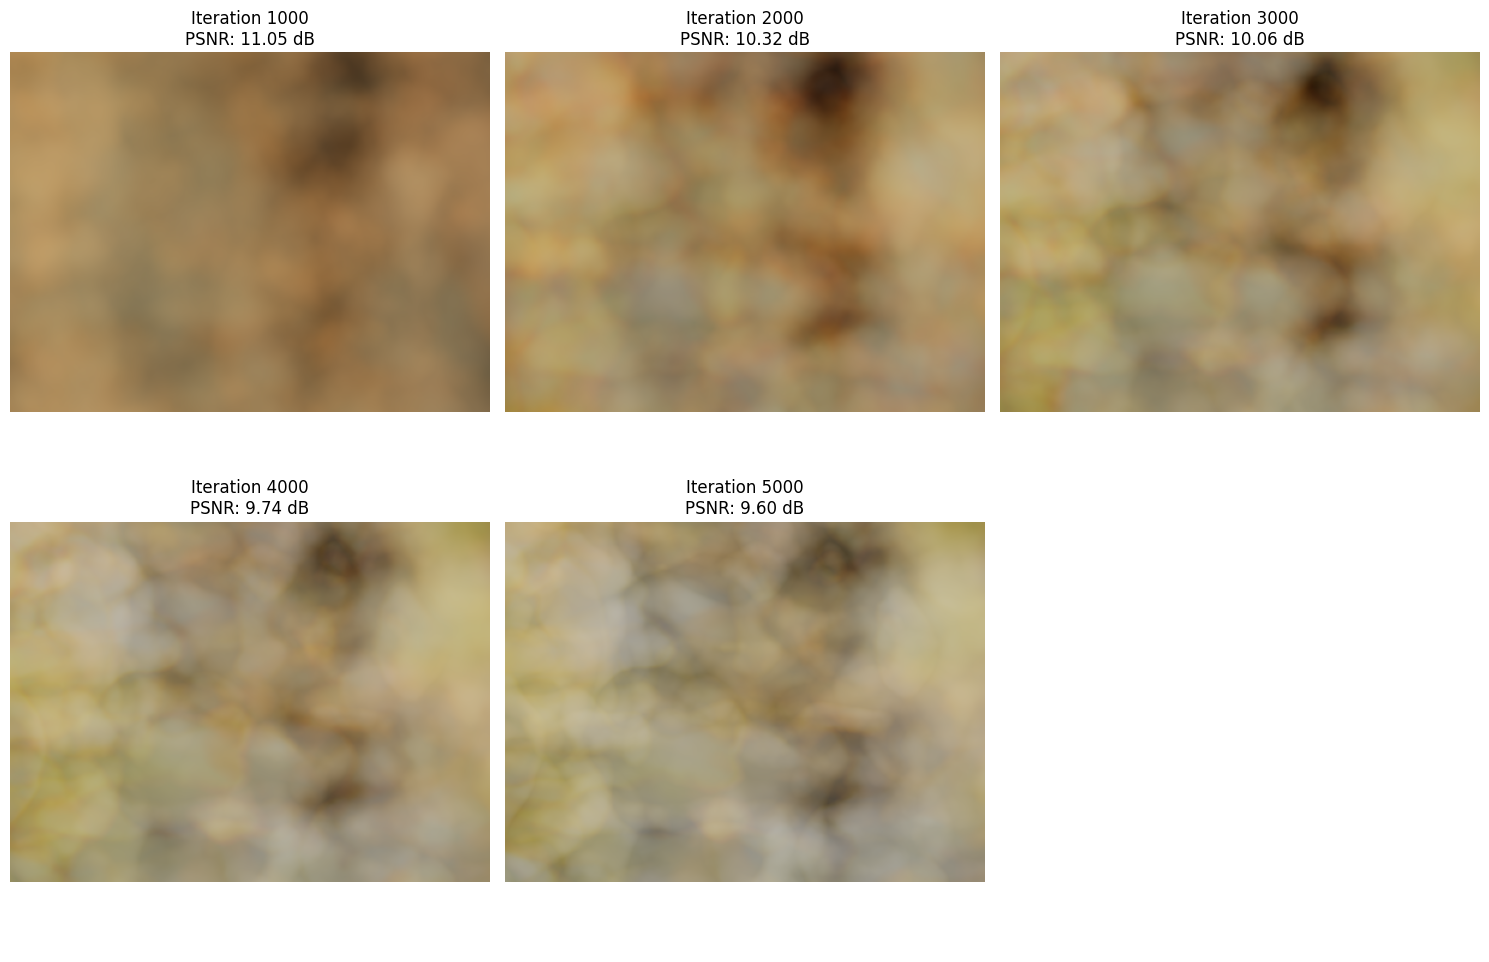


COMPARISON: Ground Truth vs All Checkpoints


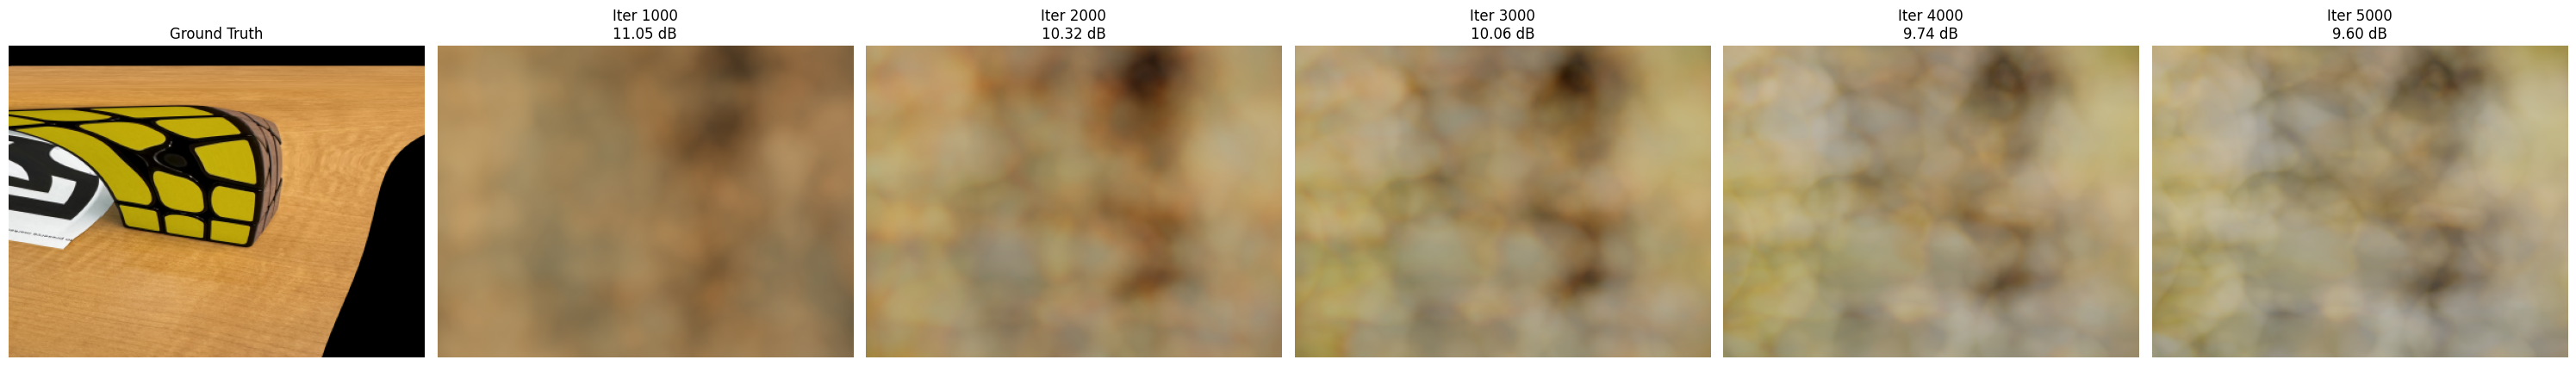


✓ Rendered images from 5 checkpoints!
  PSNR progression: ['11.05', '10.32', '10.06', '9.74', '9.60']


In [22]:
print("=" * 70)
print("RENDERING FROM ALL CHECKPOINTS")
print("=" * 70)

import glob
import re

# Find all checkpoint files
checkpoint_dir = "checkpoints"
checkpoint_files = glob.glob(os.path.join(checkpoint_dir, "nerf_checkpoint_*.pth"))

# Sort by iteration number
def get_iteration(filename):
    match = re.search(r'nerf_checkpoint_(\d+)\.pth', filename)
    return int(match.group(1)) if match else 0

checkpoint_files.sort(key=get_iteration)

print(f"Found {len(checkpoint_files)} checkpoints:")
for cp_file in checkpoint_files:
    iteration = get_iteration(cp_file)
    print(f"  - {cp_file} (iteration {iteration})")

if len(checkpoint_files) == 0:
    print("⚠️  No checkpoints found!")
else:
    # Use first validation image for rendering
    val_idx = 0
    val_image = images_val[val_idx]
    val_c2w = c2ws_val[val_idx]
    
    # Store rendered images
    rendered_images = []
    checkpoint_iterations = []
    checkpoint_psnrs = []
    
    # Render from each checkpoint
    for cp_file in checkpoint_files:
        iteration = get_iteration(cp_file)
        print(f"\n{'='*70}")
        print(f"Loading checkpoint: {cp_file} (iteration {iteration})")
        print(f"{'='*70}")
        
        # Load checkpoint
        checkpoint = torch.load(cp_file, map_location=device, weights_only=False)
        
        # Create a fresh model instance
        checkpoint_model = NeRF(
            pe_L_coords=pe_L_coords,
            pe_L_viewdir=pe_L_viewdir,
            hidden_dim=hidden_dim,
            num_layers=num_layers
        ).to(device)
        
        # Load model state
        checkpoint_model.load_state_dict(checkpoint['model_state_dict'])
        checkpoint_model.eval()
        
        # Render validation image
        rendered = np.zeros((H, W, 3))
        
        # Vectorized ray generation
        u, v = np.meshgrid(np.arange(W), np.arange(H))
        u = u.flatten()
        v = v.flatten()
        uv = np.stack([u, v], axis=-1)
        
        # Generate all rays at once
        rays_o, rays_d = pixel_to_ray(K, val_c2w, uv)
        
        # Process in batches to avoid memory issues
        batch_size_render = 4096
        with torch.no_grad():
            for i in range(0, len(rays_o), batch_size_render):
                batch_rays_o = rays_o[i:i+batch_size_render]
                batch_rays_d = rays_d[i:i+batch_size_render]
                batch_uv = uv[i:i+batch_size_render]
                
                # Sample along rays
                points, t_vals = sample_along_rays(
                    batch_rays_o, batch_rays_d,
                    near=near, far=far,
                    n_samples=n_samples,
                    perturb=False  # No perturbation during inference
                )
                
                # Convert to tensors
                points_tensor = torch.from_numpy(points).float().to(device)
                viewdirs_tensor = torch.from_numpy(batch_rays_d).float().to(device)
                viewdirs_tensor = viewdirs_tensor[:, None, :].expand(-1, n_samples, -1)
                
                # Forward pass
                densities, colors = checkpoint_model(points_tensor, viewdirs_tensor)
                
                # Volume rendering
                rendered_colors, _ = volume_render_torch(
                    densities.squeeze(-1),
                    colors,
                    torch.from_numpy(t_vals).float().to(device),
                    torch.from_numpy(batch_rays_d).float().to(device)
                )
                
                # Store rendered colors
                rendered_colors_np = rendered_colors.cpu().numpy()
                for j, (u_pix, v_pix) in enumerate(batch_uv):
                    rendered[v_pix, u_pix] = rendered_colors_np[j]
        
        # Clip to [0, 1]
        rendered = np.clip(rendered, 0, 1)
        
        # Compute PSNR
        mse = np.mean((rendered - val_image) ** 2)
        psnr = -10 * np.log10(mse) if mse > 0 else float('inf')
        
        rendered_images.append(rendered)
        checkpoint_iterations.append(iteration)
        checkpoint_psnrs.append(psnr)
        
        print(f"  ✓ Rendered image from iteration {iteration}: PSNR = {psnr:.2f} dB")
    
    # Display all rendered images in a grid
    print(f"\n{'='*70}")
    print("DISPLAYING ALL CHECKPOINT RENDERS")
    print(f"{'='*70}")
    
    num_checkpoints = len(rendered_images)
    cols = min(3, num_checkpoints)
    rows = (num_checkpoints + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    if num_checkpoints == 1:
        axes = axes.reshape(1, 1)
    elif rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)
    
    for idx in range(num_checkpoints):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col] if rows > 1 else axes[col]
        
        ax.imshow(rendered_images[idx])
        ax.set_title(f"Iteration {checkpoint_iterations[idx]}\nPSNR: {checkpoint_psnrs[idx]:.2f} dB")
        ax.axis('off')
    
    # Hide unused subplots
    for idx in range(num_checkpoints, rows * cols):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col] if rows > 1 else axes[col]
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Also create a comparison with ground truth
    print(f"\n{'='*70}")
    print("COMPARISON: Ground Truth vs All Checkpoints")
    print(f"{'='*70}")
    
    fig, axes = plt.subplots(1, num_checkpoints + 1, figsize=(5*(num_checkpoints + 1), 5))
    
    # Show ground truth first
    axes[0].imshow(val_image)
    axes[0].set_title("Ground Truth")
    axes[0].axis('off')
    
    # Show each checkpoint render
    for idx in range(num_checkpoints):
        axes[idx + 1].imshow(rendered_images[idx])
        axes[idx + 1].set_title(f"Iter {checkpoint_iterations[idx]}\n{checkpoint_psnrs[idx]:.2f} dB")
        axes[idx + 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Rendered images from {num_checkpoints} checkpoints!")
    print(f"  PSNR progression: {[f'{p:.2f}' for p in checkpoint_psnrs]}")



In [19]:
# Generate GIF of cube NeRF with novel views
# Create a circular camera path around the object

import math
import numpy as np

def look_at_origin(pos):
    """Camera looks towards the origin"""
    forward = -pos / np.linalg.norm(pos)  # Normalize the direction vector
    # Define up vector (assuming y-up)
    up = np.array([0, 1, 0])
    # Compute right vector using cross product
    right = np.cross(up, forward)
    right = right / np.linalg.norm(right)
    # Recompute up vector to ensure orthogonality
    up = np.cross(forward, right)
    # Create the camera-to-world matrix
    c2w = np.eye(4)
    c2w[:3, 0] = right
    c2w[:3, 1] = up
    c2w[:3, 2] = forward
    c2w[:3, 3] = pos
    return c2w

def rot_x(phi):
    """Rotation around x-axis"""
    return np.array([
        [math.cos(phi), -math.sin(phi), 0, 0],
        [math.sin(phi), math.cos(phi), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ])

# Determine a good starting position from training camera extrinsics
# Use the average camera position as reference
if len(c2ws_train) > 0:
    avg_camera_pos = np.mean([c2w[:3, 3] for c2w in c2ws_train], axis=0)
    # Use a position at a reasonable distance
    START_POS = avg_camera_pos * 1.5  # Scale up a bit
    # Ensure minimum distance
    if np.linalg.norm(START_POS) < 0.1:
        START_POS = np.array([0.3, 0.2, 0.3])
else:
    START_POS = np.array([0.3, 0.2, 0.3])

NUM_SAMPLES = 60  # Number of frames in the GIF

print("Generating circular camera path for cube NeRF...")
print("=" * 70)
print(f"Starting position: {START_POS}")
print(f"Number of frames: {NUM_SAMPLES}")

# Generate camera poses for circular path
circular_c2ws = []
for phi in np.linspace(360., 0., NUM_SAMPLES, endpoint=False):
    c2w = look_at_origin(START_POS)
    extrinsic = rot_x(phi/180.*np.pi) @ c2w
    circular_c2ws.append(extrinsic)

print(f"✓ Generated {len(circular_c2ws)} camera poses")

# Render frames from these camera poses
print("\nRendering frames for GIF...")
model.eval()

frames_cube = []

for frame_idx, c2w_circular in enumerate(circular_c2ws):
    if (frame_idx + 1) % 10 == 0:
        print(f"  Rendering frame {frame_idx + 1}/{NUM_SAMPLES}...")
    
    # Generate all rays for this camera
    y_coords, x_coords = np.meshgrid(
        np.arange(H), 
        np.arange(W), 
        indexing='ij'
    )
    all_uvs = np.stack([x_coords.flatten() + 0.5, y_coords.flatten() + 0.5], axis=1)
    rays_o_circular, rays_d_circular = pixel_to_ray(K, c2w_circular, all_uvs)
    
    # Render in batches
    batch_size_render = 4096
    rendered_pixels = []
    
    with torch.no_grad():
        for i in range(0, len(rays_o_circular), batch_size_render):
            batch_rays_o = rays_o_circular[i:i+batch_size_render]
            batch_rays_d = rays_d_circular[i:i+batch_size_render]
            
            batch_points, batch_t_vals = sample_along_rays(
                batch_rays_o, batch_rays_d,
                near=near, far=far,
                n_samples=n_samples,
                perturb=False
            )
            
            batch_points_tensor = torch.from_numpy(batch_points).float().to(device)
            batch_viewdirs_tensor = torch.from_numpy(batch_rays_d).float().to(device)
            batch_viewdirs_tensor = batch_viewdirs_tensor[:, None, :].expand(-1, n_samples, -1)
            
            batch_densities, batch_colors = model(batch_points_tensor, batch_viewdirs_tensor)
            
            # Volume render
            batch_rendered, _ = volume_render_torch(
                batch_densities.squeeze(-1),
                batch_colors,
                torch.from_numpy(batch_t_vals).float().to(device),
                torch.from_numpy(batch_rays_d).float().to(device)
            )
            
            rendered_pixels.append(batch_rendered.cpu().numpy())
    
    rendered_pixels = np.concatenate(rendered_pixels, axis=0)
    rendered_frame = rendered_pixels.reshape(H, W, 3)
    
    # Clip to [0, 1] and convert to uint8
    rendered_frame = np.clip(rendered_frame, 0, 1)
    rendered_frame_uint8 = (rendered_frame * 255).astype(np.uint8)
    
    frames_cube.append(rendered_frame_uint8)

# Save as GIF
try:
    import imageio
    gif_path_cube = 'cube_nerf_novel_views.gif'
    print(f"\nSaving GIF to {gif_path_cube}...")
    imageio.mimsave(gif_path_cube, frames_cube, duration=0.15, loop=0)
    print(f"✓ GIF saved: {gif_path_cube}")
except ImportError:
    print("\n⚠ imageio not available. Install with: pip install imageio")
    print("Frames are stored in 'frames_cube' variable. You can save them manually.")

# Also save first few frames as images for preview
print("\nSaving preview frames...")
for i in [0, len(frames_cube)//4, len(frames_cube)//2, 3*len(frames_cube)//4, len(frames_cube)-1]:
    if i < len(frames_cube):
        plt.figure(figsize=(8, 6))
        plt.imshow(frames_cube[i])
        plt.axis('off')
        plt.title(f'Frame {i+1}/{len(frames_cube)}')
        plt.savefig(f'cube_frame_{i+1}.png', dpi=150, bbox_inches='tight')
        plt.close()

print("✓ Preview frames saved")
print("\n✓ Cube NeRF GIF generation complete!")


Generating circular camera path for cube NeRF...
Starting position: [0.3 0.2 0.3]
Number of frames: 60
✓ Generated 60 camera poses

Rendering frames for GIF...
  Rendering frame 10/60...
  Rendering frame 20/60...
  Rendering frame 30/60...
  Rendering frame 40/60...
  Rendering frame 50/60...
  Rendering frame 60/60...

Saving GIF to cube_nerf_novel_views.gif...
✓ GIF saved: cube_nerf_novel_views.gif

Saving preview frames...
✓ Preview frames saved

✓ Cube NeRF GIF generation complete!
